# Data Exploration Dataset 

The goal of this notebooks is to understand the structure and characteristics of the dataset.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
df_pd = pd.read_parquet("../revisions_no_bots.parquet")
df = pl.from_pandas(df_pd)
df

revid,parentid,minor,user,userid,timestamp,size,slots,tags,pageid,title
i64,i64,bool,str,f64,str,i64,struct[1],list[str],i64,str
1163683705,1073278143,false,"""Smasongarrison""",1.6185737e7,"""2023-07-06T02:12:52Z""",14787,"{{""wikitext"",14787}}","[""AWB""]",57185536,"""Georgia Hopley"""
1170257280,1169998062,true,"""Smasongarrison""",1.6185737e7,"""2023-08-14T00:52:02Z""",39439,"{{""wikitext"",39439}}",[],15394015,"""Willis Ward"""
1162127828,1160202917,true,"""Minorax""",3.6529075e7,"""2023-06-27T04:21:11Z""",39390,"{{""wikitext"",39390}}","[""wikieditor""]",15394015,"""Willis Ward"""
1160202917,1160202005,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:20:50Z""",39421,"{{""wikitext"",39421}}","[""visualeditor""]",15394015,"""Willis Ward"""
1160202005,1152748211,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:11:16Z""",38839,"{{""wikitext"",38839}}","[""visualeditor""]",15394015,"""Willis Ward"""
…,…,…,…,…,…,…,…,…,…,…
1135099269,1120571467,true,"""Gaius Cornelius""",293907.0,"""2023-01-22T16:53:40Z""",45682,"{{""wikitext"",45682}}","[""AWB""]",62440986,"""44 Union Square"""
1162413149,1161172203,false,"""ForsythiaJo""",4.4933079e7,"""2023-06-29T00:38:45Z""",12490,"{{""wikitext"",12490}}","[""wikieditor""]",47872332,"""The Pioneer Mother Memorial"""
1161172203,1161172179,false,"""Another Believer""",5.886041e6,"""2023-06-21T03:09:24Z""",12483,"{{""wikitext"",12483}}","[""visualeditor""]",47872332,"""The Pioneer Mother Memorial"""


## Create Graph - Reviewers+ Pages

L = 233650 
N = 43113 + 36048

In [3]:
graph_rev_pag = (
    df
    .select(["userid", "pageid"])
    .unique()
)
graph_rev_pag

userid,pageid
f64,i64
4.4498245e7,41585179
3.093817e6,930379
6.262758e6,2681142
6.479619e6,3117124
1.2971673e7,27885687
…,…
1.6185737e7,551755
820190.0,20198436
1.7171546e7,2260421


In [4]:
graph_rev_pag.select("userid").unique().count()

userid
u32
43113


In [5]:
graph_rev_pag.select("pageid").unique().count()

pageid
u32
36048


## Projeção Users

In [21]:
clone_graph = graph_rev_pag.clone().rename({"userid": "userid_2"})

## Create a df with users conneting to users via pages and the total of pages shared
graph_users = (
    graph_rev_pag
    .join(clone_graph, left_on="pageid", right_on="pageid", how="left")
    .filter(pl.col("userid") != pl.col("userid_2"))
    .rename({"userid": "from", "userid_2": "to"})
    .select(["from", "to"])
    .unique()
    
)

## with no commmon pages between users
no_interaction_users = (
    graph_rev_pag
    .select("userid")
    .unique()
    .join(
        graph_users.select("from").unique(),
        left_on="userid",
        right_on="from",
        how="anti"
    )
    .rename({"userid": "from"})
    .with_columns(pl.lit(None).alias("to"))
)

graph_users = graph_users.vstack(no_interaction_users)
graph_users.write_ipc("reviewers_graph.feather", compression="zstd")
graph_users.head()

from,to
f64,f64
4.5520777e7,4.5515413e7
2.9493386e7,3.6972456e7
3.6469351e7,1.522828e6
9.280205e6,4.6382046e7
1.224855e6,4.2677165e7


In [20]:
## calculate the the number of users (nodes) and the number of connections (edges)
L = graph_users.select("from").shape[0]/2
N = graph_users.select("from").unique().shape[0]
L, N

(2092557.0, 43113)

C:\Users\Caio\AppData\Local\Temp\ipykernel_11416\795663341.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


<Axes: xlabel='k', ylabel='p_k'>

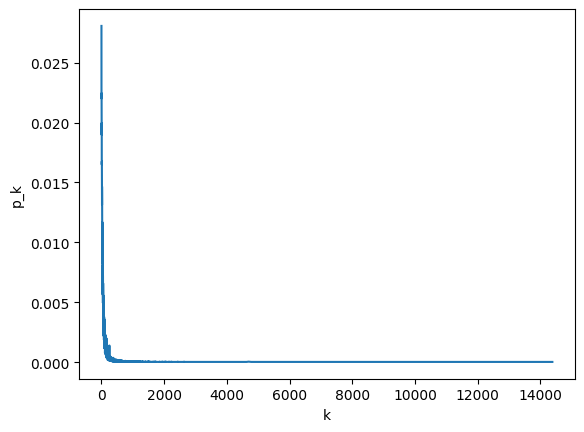

In [22]:
## degree neighboors
_from = (
    graph_users
    .group_by("from")
    .count()
    .sort("count", descending=True)
)

_hist_k_prob = (
    _from
    .rename({"count": "k"})
    .group_by("k")
    .agg(pl.count("k").alias("count_k"))
    .with_columns(
        (pl.col("count_k") / pl.lit(_from.shape[0])).alias("p_k")
    )
    .select(["k", "p_k"])

)

sns.lineplot(data=_hist_k_prob.to_pandas(), x="k", y="p_k")
